# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 70°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 443
Average Fx in the averaging interval [730:1173]: 5.5025732033946975
Average Fz in the averaging interval [730:1173]: 0.7799903335743511
Maximum Fz in the plotting interval [730:1225]: 1.734521484375 at timestep 1156
Time step where Fx drops below 1: 1174


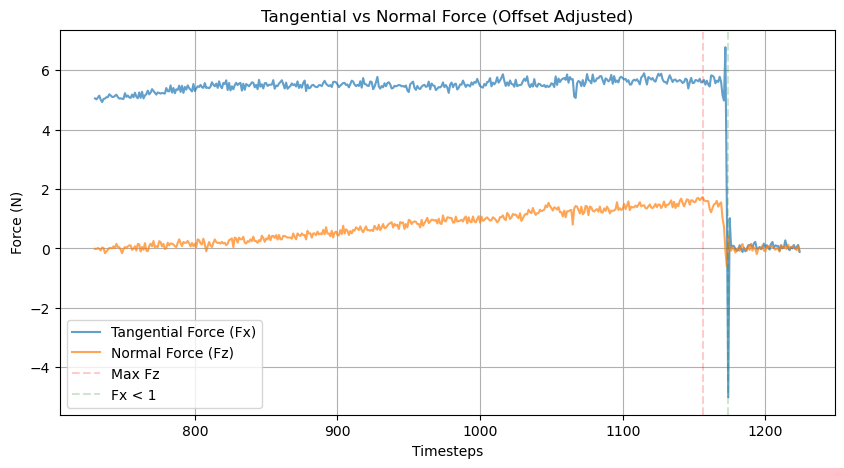

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405231956.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=730, cut_2=1225, avg_end=1173, offset_position='end', offset_length=20)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 173
Average Fx in the averaging interval [1365:1538]: 5.222540412472852
Average Fz in the averaging interval [1365:1538]: 0.4195063243711615
Maximum Fz in the plotting interval [1365:None]: 0.7814056396484375 at timestep 1524
Time step where Fx drops below 1: 1539


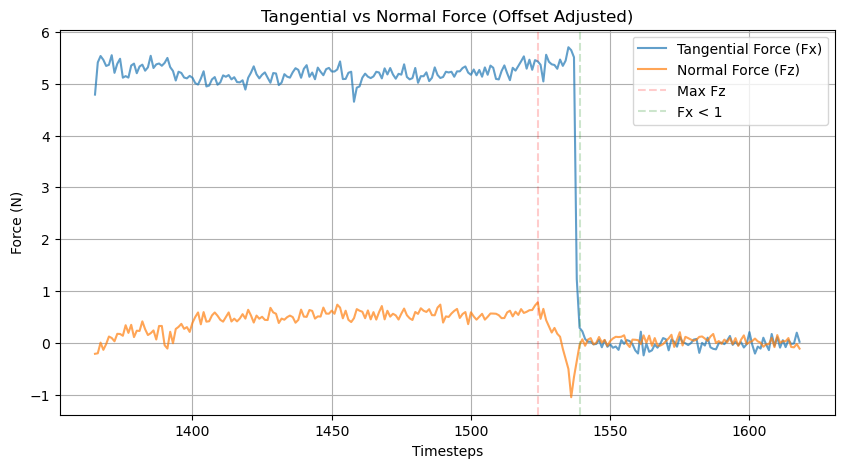

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405231957.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1365, cut_2=None, avg_end=1538, offset_position='end', offset_length=20)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 187
Average Fx in the averaging interval [970:1157]: 4.439471600782426
Average Fz in the averaging interval [970:1157]: 0.3099344508533172
Maximum Fz in the plotting interval [970:1200]: 0.8687713623046875 at timestep 1149
Time step where Fx drops below 1: 1157


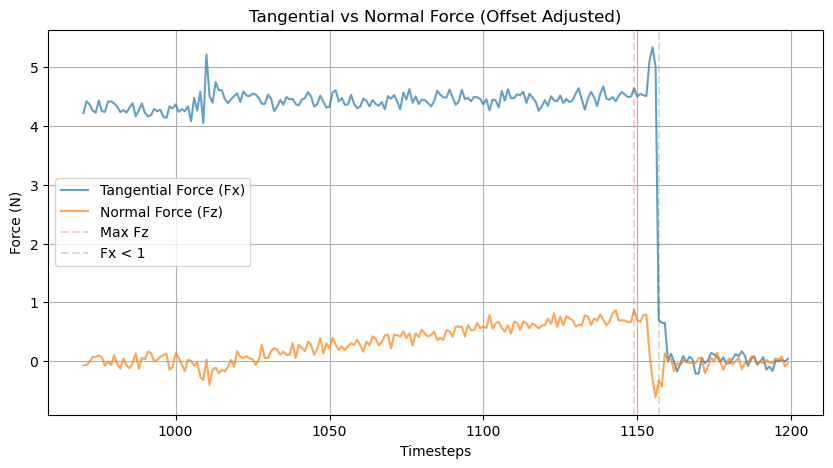

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405231959.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=970, cut_2=1200, avg_end=1157, offset_position='end', offset_length=20)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 406
Average Fx in the averaging interval [1030:1436]: 5.403732067101891
Average Fz in the averaging interval [1030:1436]: 0.7112957633383364
Maximum Fz in the plotting interval [1030:None]: 1.5048909505208332 at timestep 1406
Time step where Fx drops below 1: 1437


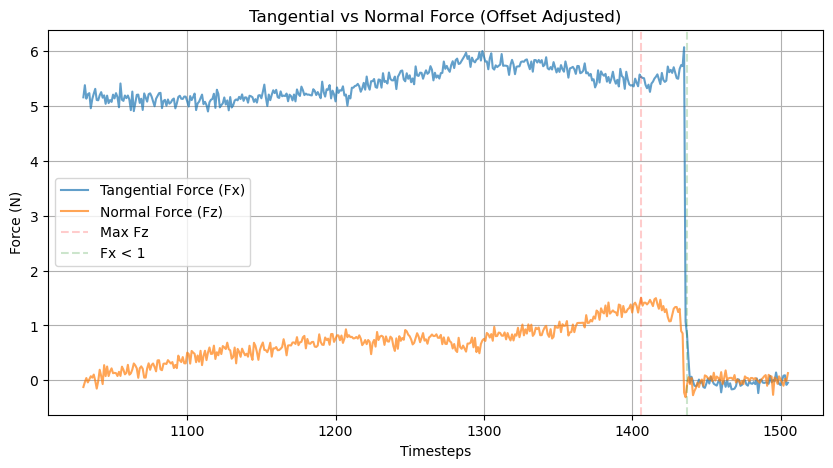

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232000.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=1030, cut_2=None, avg_end=1436, offset_position='end', offset_length=15)

<font size="6">Test 5a: (worked)</font>

Length from cut_1 to avg_end: 150
Average Fx in the averaging interval [775:925]: 5.414022324879965
Average Fz in the averaging interval [775:925]: 0.31474934895833334
Maximum Fz in the plotting interval [775:970]: 0.7867635091145833 at timestep 900
Time step where Fx drops below 1: 925


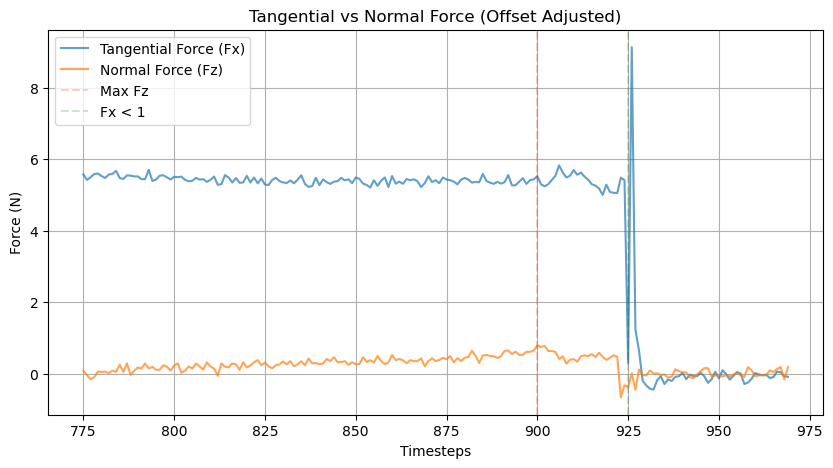

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232001.csv"
df = pd.read_csv(data)
test_5a, end_5a = plot_forces(df, cut_1=775, cut_2=970, avg_end=925, offset_position='end', offset_length=15)

<font size="6">Test 5b: (worked)</font>

Length from cut_1 to avg_end: 129
Average Fx in the averaging interval [1013:1142]: 3.8152085644330165
Average Fz in the averaging interval [1013:1142]: 0.7714545671329942
Maximum Fz in the plotting interval [1013:1180]: 1.0663655598958333 at timestep 1131
Time step where Fx drops below 1: 1142


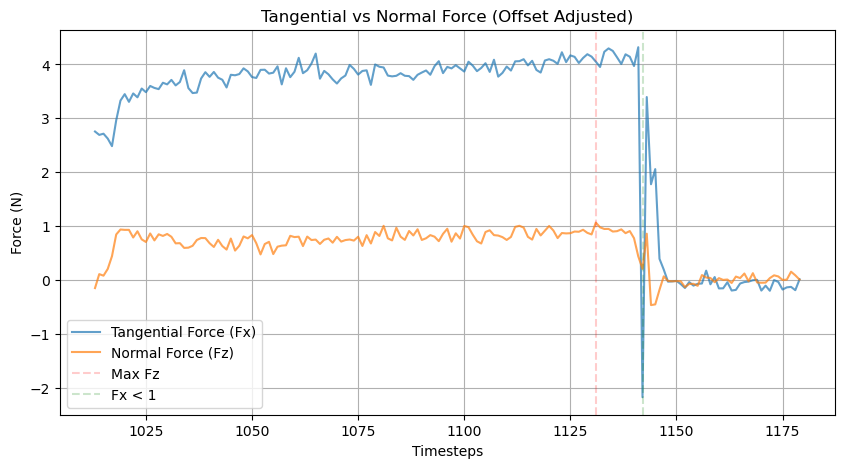

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232001.csv"
df = pd.read_csv(data)
test_5b, end_5b = plot_forces(df, cut_1=1013, cut_2=1180, avg_end=1142, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 255
Average Fx in the averaging interval [1150:1405]: 4.882850022409477
Average Fz in the averaging interval [1150:1405]: 0.32122252221200975
Maximum Fz in the plotting interval [1150:1450]: 0.9373331705729167 at timestep 1293
Time step where Fx drops below 1: 1405


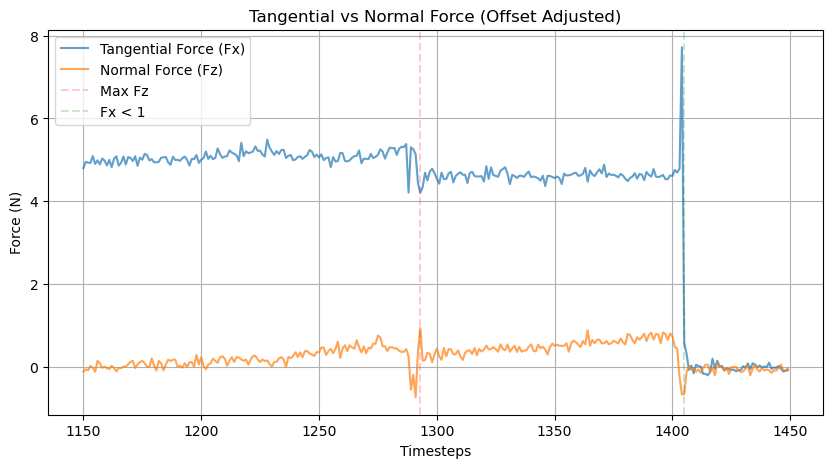

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232002.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1150, cut_2=1450, avg_end=1405, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 457
Average Fx in the averaging interval [845:1302]: 5.402246842499113
Average Fz in the averaging interval [845:1302]: 0.8755573921008843
Maximum Fz in the plotting interval [845:None]: 1.7832071940104166 at timestep 1200
Time step where Fx drops below 1: 1302


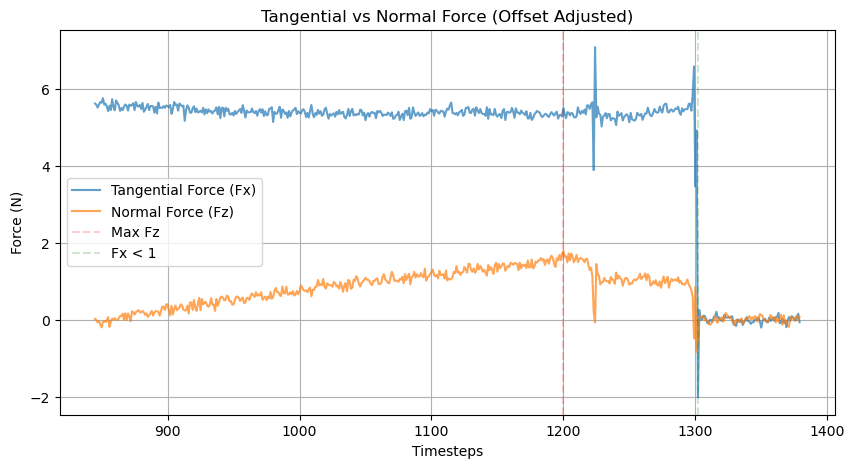

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232003.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=845, cut_2=None, avg_end=1302, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 191
Average Fx in the averaging interval [1000:1191]: 4.654100163777669
Average Fz in the averaging interval [1000:1191]: 0.0813332762393652
Maximum Fz in the plotting interval [1000:1250]: 0.37486572265625 at timestep 1117
Time step where Fx drops below 1: 1191


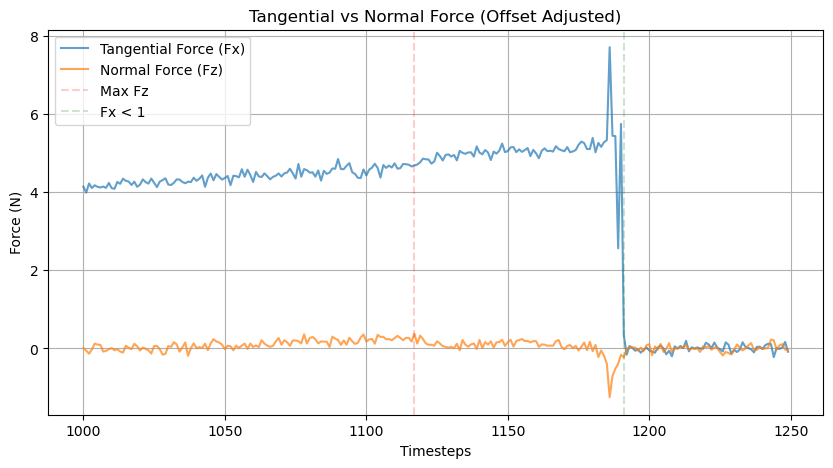

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232004.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=1000, cut_2=1250, avg_end=1191, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 306
Average Fx in the averaging interval [1350:1656]: 5.770616096297121
Average Fz in the averaging interval [1350:1656]: 0.6408649519378065
Maximum Fz in the plotting interval [1350:1700]: 1.66326904296875 at timestep 1647
Time step where Fx drops below 1: 1656


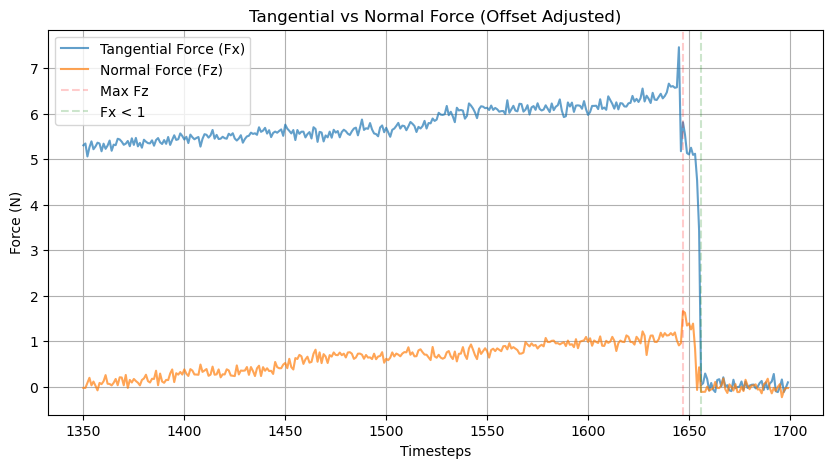

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232005.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=1350, cut_2=1700, avg_end=1656, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 223
Average Fx in the averaging interval [950:1173]: 4.711464711832181
Average Fz in the averaging interval [950:1173]: 0.5996105245410593
Maximum Fz in the plotting interval [950:None]: 1.16719970703125 at timestep 1158
Time step where Fx drops below 1: 1173


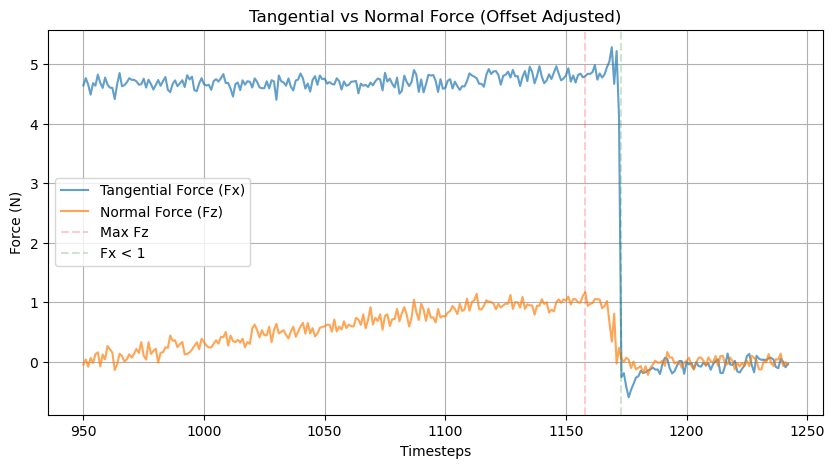

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_70_5N//log_202405232007.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=950, cut_2=None, avg_end=1173, offset_position='end', offset_length=15)

In [14]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [18]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//70//Asphalt_70_stats.csv", index=False)

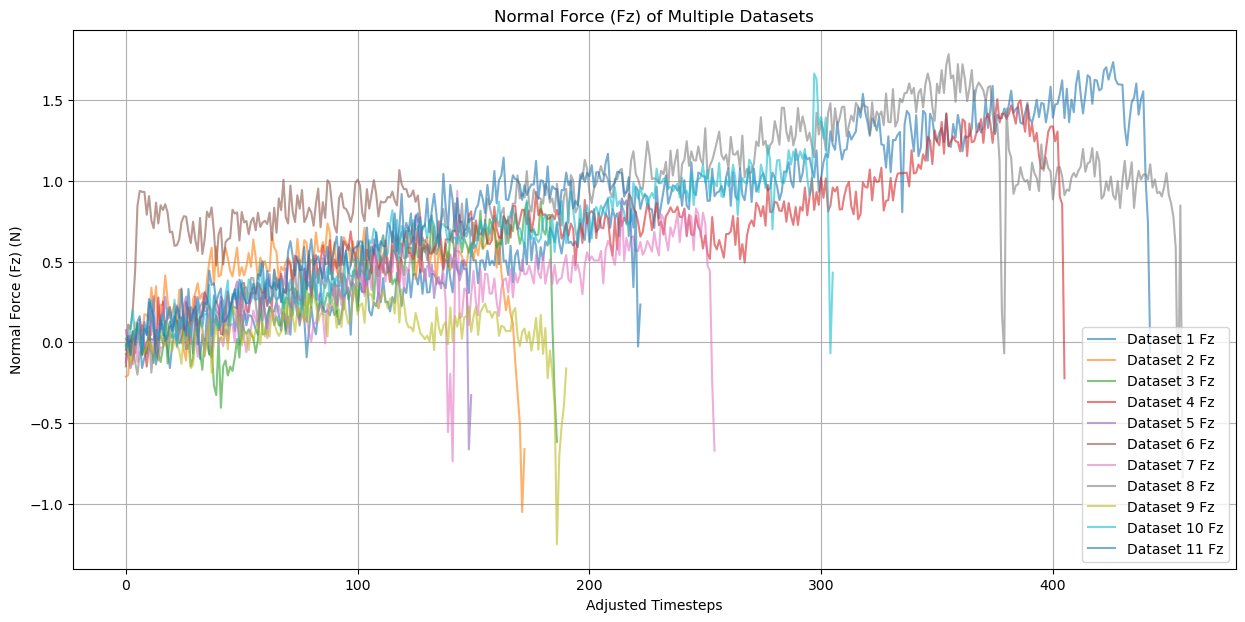

Average of maximum Fz forces: 1.151690303918087
Standard deviation of maximum Fz forces: 0.4402706771017967
Average of average Fz forces: 0.5295926777508744
Standard deviation of average Fz forces: 0.2415986120652042
Average of average Fx forces: 5.019893273625491
Standard deviation of average Fx forces: 0.5495752831654012


In [19]:
tests = [test_1, test_2, test_3, test_4, test_5a, test_5b, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5a, end_5b, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [20]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//70//Asphalt_70"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)